# Fano-factor PSTHs by brain region and LDA-1 bin, and single-neuron Fano factor vs LDA-1
Two things happen here:
1. A descriptive, condition-adjusted Fano-factor PSTH (var of side x contrast residuals / mean of
   windowed spike counts) per session x region, averaged across sessions within each LDA-1 bin
   (unchanged from before -- causal smoothing window, correct-trials only, region selection).
2. A single-neuron Fano factor computed the way the paper does it: one Fano factor value per
   neuron for a fixed pre-stimulus window and one for a fixed post-stimulus window (no smoothing,
   no time course), tested for a relationship with `lda_1` via a GLM + session-stratified
   permutation test + Bayes factor, mirroring the paper's age-effect analysis with `lda_1` in
   place of `age_years`.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from scipy.stats import pearsonr
from iblatlas.regions import BrainRegions
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [53]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/'

REGION_LEVEL = 'cosmos'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
WIN_BINS = 6               # ~100 ms sliding window -- descriptive PSTH-by-bin plot only
SMOOTH_MODE = 'causal'     # 'causal' (only bins <= t) or 'centered'
MIN_NEURONS = 15           # per region in a session
N_BINS = 5                 # LDA-1 bins -- descriptive PSTH-by-bin plot only
REMOVE_CONDITION = True    # subtract stimulus (side x contrast) means before variance (mean-matched FF)
BALANCE_SESSIONS = False   # subsample each session to a common trial count -- descriptive curve only
SESSION_N_TARGET = 200     # trials per session when balancing (sessions with fewer are skipped)
N_SUBSAMPLE_REPEATS = 10   # average FF over this many random subsamples
N_NEURONS_CAP = None       # cap on neurons used for the descriptive curve only (None = no cap)
MIN_MEAN_COUNT = 0.01      # per-bin mean-count floor, descriptive curve only (FF unstable at low counts)
SEED = 0
CORRECT_ONLY = False     # if True, use only correct trials

# --- paper-style single-neuron Fano factor (fixed pre-/post-stimulus windows, no smoothing) ---
PRE_WINDOW = (-0.2, 0.0)    # baseline window (s)
POST_WINDOW = (0.1, 0.3)    # post-stimulus window (s)
MIN_TRIALS = 40             # min correct trials per session-region to trust a window FF estimate
MIN_WINDOW_COUNT = 0.5      # min mean spike count within the window (FF unstable below this)
N_PERM = 2000               # permutation iterations (matches the paper's neural-metric count)

# --- quench onset (per-neuron derivative-threshold onset latency), matching the "## Timing of
# quench onset" section of ff_quench.ipynb (a different, more sophisticated algorithm than the
# simple peak/trough-later-time approach used earlier in that same notebook) ---
SEARCH_WINDOW = (-0.2, 0.2)          # window the smoothed FF curve and its derivative are computed over
PEAK_SEARCH_WINDOW = (-0.05, 0.08)   # narrow window to locate the pre-quench "bump" peak
ONSET_THRESHOLD_FRAC = 0.25          # onset = where the derivative first hits this fraction of its post-peak minimum
SMOOTH_SIGMA = 1.0                   # Gaussian-smoothing sigma (in bins, ~binwidth s) before derivative/peak detection

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut06-07-2026').rename(columns={0: 'lda_1'})
lda['bin'] = lda['binned1'].cat.codes
bin_map = dict(zip(lda['session'], lda['bin']))
lda1_map = dict(zip(lda['session'], lda['lda_1']))
# trials_df = pd.read_parquet(prefix + '4_mice/all_trials_04-05-2026')  # deprecated - silently dropped no-go trials
trials_df = pd.read_parquet(prefix + '4_mice/session_trial_meta_06-07-2026')
correct_by_session = trials_df[trials_df['feedback'] == 'correct'].groupby('session')['trial_id'].apply(set).to_dict()
br = BrainRegions()
print(f"LDA sessions: {lda['session'].nunique()}, bins: {sorted(lda['bin'].unique())}")

LDA sessions: 248, bins: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]


## Compute Fano factor per session x region: descriptive PSTH curve + paper-style single-neuron pre/post windows

In [54]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)
binwidth = float(np.median(np.diff(tsec)))
pre_mask = (tsec >= PRE_WINDOW[0]) & (tsec < PRE_WINDOW[1])
post_mask = (tsec >= POST_WINDOW[0]) & (tsec < POST_WINDOW[1])
search_mask = (tsec >= SEARCH_WINDOW[0]) & (tsec <= SEARCH_WINDOW[1])
t_search = tsec[search_mask]
peak_search_local_mask = (t_search >= PEAK_SEARCH_WINDOW[0]) & (t_search <= PEAK_SEARCH_WINDOW[1])
# Gaussian smoothing (sigma=SMOOTH_SIGMA) needs real data on both sides of the search window to
# avoid edge artifacts at the window boundary, exactly like ff_quench.ipynb smoothing the FULL
# curve before slicing to the window -- pad by the kernel's effective radius (truncate=4.0 is
# scipy's default), smooth over the padded range, then slice back down to search_mask.
_search_idx = np.where(search_mask)[0]
_pad_bins = int(4 * SMOOTH_SIGMA) + 1
_pad_lo = max(0, _search_idx[0] - _pad_bins)
_pad_hi = min(T, _search_idx[-1] + 1 + _pad_bins)
pad_mask = np.zeros(T, dtype=bool); pad_mask[_pad_lo:_pad_hi] = True
_pad_offset = _search_idx[0] - _pad_lo   # position of the true search window within the padded slice

def smooth_time(A, W, mode):
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    if mode == 'leading':
        # Forward-looking window: value at t uses bins [t, t+W) -- matches the window direction
        # used to build the original psths_fanofactor_per_neuron_all_regions file
        # (fano_factor_computation.ipynb), needed to replicate its quench-onset timing.
        c = np.cumsum(A, axis=2); Tn = A.shape[2]; out = np.empty_like(A)
        out[..., :Tn - W] = (c[..., W:] - c[..., :Tn - W]) / W
        for k in range(W):
            idx = Tn - W + k
            prev = c[..., idx - 1] if idx > 0 else 0.0
            out[..., idx] = (c[..., -1] - prev) / (Tn - idx)
        return out
    c = np.cumsum(A, axis=2); out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1)
    out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

def ff_curve(A, cond=None):
    """A: neurons x trials x T (windowed spike counts). Condition-adjusted mean Fano factor per
    time bin, averaged across neurons -- descriptive curve only."""
    mean = np.nanmean(A, axis=1)
    if REMOVE_CONDITION and cond is not None:
        resid = A.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(A, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= MIN_MEAN_COUNT) | ~np.isfinite(ff)] = np.nan
    return np.nanmean(ff, axis=0)

def window_ff(counts, cond):
    """counts: neurons x trials, window-summed spike counts for a single fixed window (pre- or
    post-stimulus). Per-neuron condition-adjusted (mean-matched) Fano factor: variance of
    per-condition-mean-subtracted counts / raw mean count -- same mean-matching as ff_curve,
    collapsed to one window instead of a smoothed time course. This is the paper's single-neuron
    FF metric ("(pre, post) Fano Factor")."""
    mean = np.nanmean(counts, axis=1)
    if REMOVE_CONDITION:
        resid = counts.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci] -= np.nanmean(counts[:, ci], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(counts, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= MIN_WINDOW_COUNT) | ~np.isfinite(ff)] = np.nan
    return ff

def neuron_ff_timecourse(A, cond, min_count):
    """A: neurons x trials x T (windowed spike counts). Same mean-matched Fano factor as ff_curve/
    window_ff, but kept per-neuron AND per-time-bin (neither axis collapsed) -- used to find each
    neuron's own FF peak/trough for the quench-onset metric."""
    mean = np.nanmean(A, axis=1)
    if REMOVE_CONDITION:
        resid = A.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(A, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= min_count) | ~np.isfinite(ff)] = np.nan
    return ff

_functional_cache = {}
def functional_group_map(area_acronyms):
    """Replicates fano_factor_computation.ipynb / ff_quench.ipynb's ad-hoc region grouping used
    as the quench-onset region covariate: singles out Hippocampus/Thalamus/Visual/Motor/
    Somatosensory cortex by name/ancestry, falls back to the Cosmos parent otherwise."""
    unique_areas = [a for a in pd.unique(area_acronyms) if a not in _functional_cache
                    and not (isinstance(a, float) and np.isnan(a))]
    if unique_areas:
        cosmos_map = dict(zip(unique_areas, br.acronym2acronym(unique_areas, mapping='Cosmos')))
        for a in unique_areas:
            try:
                ancestor_acronyms = br.ancestors(ids=br.acronym2id(a))['acronym']
                if 'TH' in ancestor_acronyms or a in ['PO', 'LP']:
                    _functional_cache[a] = 'Thalamus'
                elif 'HPF' in ancestor_acronyms or a in ['CA1', 'DG']:
                    _functional_cache[a] = 'Hippocampus'
                elif 'Isocortex' in ancestor_acronyms and any(v in a for v in ['VIS', 'RSP']):
                    _functional_cache[a] = 'Visual Cortex'
                elif 'Isocortex' in ancestor_acronyms:
                    if any(m in a for m in ['MOp', 'MOs', 'MO']):
                        _functional_cache[a] = 'Motor Cortex'
                    elif any(s in a for s in ['SSp', 'SSs', 'SS']):
                        _functional_cache[a] = 'Somatosensory Cortex'
                    else:
                        _functional_cache[a] = 'Other Cortex'
                else:
                    _functional_cache[a] = cosmos_map.get(a, 'Other')
            except Exception:
                _functional_cache[a] = cosmos_map.get(a, 'Unassigned')
    return pd.Series(area_acronyms).map(_functional_cache).values

rng = np.random.default_rng(SEED)
records = []
neuron_records = []
onset_records = []
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        if session not in bin_map: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values * binwidth

        na_raw = d.groupby('nuid')['area'].first().reindex(neurons)
        neu_functional = functional_group_map(na_raw.values)
        na = na_raw
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        conds = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values
        corr_set = correct_by_session.get(session, set())
        correct_mask = np.array([t in corr_set for t in trials]) if CORRECT_ONLY else np.ones(len(trials), dtype=bool)
        valid_idx = np.where(correct_mask)[0]

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue

            # --- descriptive PSTH curve (region-averaged, unchanged from before) ---
            ni_curve = rng.choice(ni, N_NEURONS_CAP, replace=False) if (N_NEURONS_CAP and len(ni) > N_NEURONS_CAP) else ni
            Aw = smooth_time(A[ni_curve], WIN_BINS, SMOOTH_MODE) * WIN_BINS
            if BALANCE_SESSIONS:
                if len(valid_idx) < SESSION_N_TARGET: continue
                reps = []
                for _ in range(N_SUBSAMPLE_REPEATS):
                    ss = rng.choice(valid_idx, SESSION_N_TARGET, replace=False)
                    reps.append(ff_curve(Aw[:, ss, :], conds[ss]))
                curve = np.nanmean(reps, axis=0); n_used = SESSION_N_TARGET
            else:
                curve = ff_curve(Aw[:, valid_idx, :], conds[valid_idx]); n_used = len(valid_idx)
            records.append(dict(session=session, region=region, bin=bin_map[session],
                                n_neurons=len(ni_curve), n_trials=n_used, curve=curve))

            # --- paper-style single-neuron pre-/post-stimulus window Fano factor ---
            # No trial balancing/subsampling here: n_trials is kept as a covariate in the GLM
            # below instead, exactly as the paper does ("... + n_trials").
            if len(valid_idx) >= MIN_TRIALS:
                counts_pre = np.nansum(A[ni][:, valid_idx][:, :, pre_mask], axis=2)
                counts_post = np.nansum(A[ni][:, valid_idx][:, :, post_mask], axis=2)
                cond_valid = conds[valid_idx]
                ff_pre = window_ff(counts_pre, cond_valid)
                ff_post = window_ff(counts_post, cond_valid)
                keep = np.isfinite(ff_pre) & np.isfinite(ff_post)
                for nu, fp, po in zip(np.array(neurons)[ni][keep], ff_pre[keep], ff_post[keep]):
                    neuron_records.append(dict(session=session, region=region, nuid=nu,
                                               n_trials=len(valid_idx), ff_pre=fp, ff_post=po,
                                               ff_quench=fp - po))

                # --- quench onset: derivative-threshold onset latency, matching ff_quench.ipynb's
                # "## Timing of quench onset" section (NOT the earlier, simpler peak/trough-later-
                # time block in that same notebook). For each neuron: find the pre-quench "bump"
                # peak within a narrow window right at stimulus onset, then walk forward from that
                # peak to the first time the FF's rate of change crosses 25% of its steepest
                # post-peak downward slope. Falls back to the peak time if no crossing is found.
                Aw_neu = smooth_time(A[ni][:, valid_idx, :], WIN_BINS, 'leading') * WIN_BINS
                ff_t_pad = neuron_ff_timecourse(Aw_neu[:, :, pad_mask], cond_valid, MIN_MEAN_COUNT)
                finite_rows = np.all(np.isfinite(ff_t_pad), axis=1)
                if finite_rows.any() and peak_search_local_mask.any():
                    ff_smooth_pad = gaussian_filter1d(ff_t_pad[finite_rows], sigma=SMOOTH_SIGMA, axis=1)
                    ff_t_smooth = ff_smooth_pad[:, _pad_offset:_pad_offset + len(t_search)]
                    nu_ok = np.array(neurons)[ni][finite_rows]
                    func_ok = neu_functional[ni][finite_rows]
                    for row_i in range(ff_t_smooth.shape[0]):
                        ts_win = ff_t_smooth[row_i]
                        i_peak_local = np.argmax(ts_win[peak_search_local_mask])
                        t_peak = t_search[peak_search_local_mask][i_peak_local]

                        derivative = np.gradient(ts_win, binwidth)
                        after_peak_mask = t_search >= t_peak
                        deriv_after_peak = derivative[after_peak_mask]
                        min_deriv = np.min(deriv_after_peak)
                        onset_threshold = min_deriv * ONSET_THRESHOLD_FRAC
                        onset_candidates = np.where((derivative < onset_threshold) & after_peak_mask)[0]
                        onset_time = t_search[onset_candidates[0]] if len(onset_candidates) else t_peak

                        onset_records.append(dict(session=session, nuid=nu_ok[row_i],
                                                  quench_onset_time=onset_time,
                                                  functional_region=func_ok[row_i]))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Descriptive curves: {len(curves)} session-region rows | {curves['session'].nunique()} sessions | "
      f"regions: {sorted(curves['region'].unique())}")

neuron_df = pd.DataFrame(neuron_records)
neuron_df['lda_1'] = neuron_df['session'].map(lda1_map)
neuron_df['bin'] = neuron_df['session'].map(bin_map)
neuron_df['log_ff_pre'] = np.log(neuron_df['ff_pre'].clip(lower=1e-6))
neuron_df['log_ff_post'] = np.log(neuron_df['ff_post'].clip(lower=1e-6))

onset_df = pd.DataFrame(onset_records)
neuron_df = neuron_df.merge(onset_df, on=['session', 'nuid'], how='left')
print(f"Single-neuron FF table: {len(neuron_df)} neurons | {neuron_df['session'].nunique()} sessions | "
      f"regions: {neuron_df['region'].nunique()}")
print(f"Quench onset time available for {neuron_df['quench_onset_time'].notna().sum()} of {len(neuron_df)} "
      f"neurons (search window {SEARCH_WINDOW} s); functional regions: "
      f"{sorted(neuron_df['functional_region'].dropna().unique())}")

  100/380 files...
  200/380 files...
  300/380 files...
Descriptive curves: 574 session-region rows | 238 sessions | regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']
Single-neuron FF table: 18850 neurons | 238 sessions | regions: 10
Quench onset time available for 18791 of 18850 neurons (search window (-0.2, 0.2) s); functional regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HY', 'Hippocampus', 'MB', 'Motor Cortex', 'OLF', 'Other Cortex', 'Somatosensory Cortex', 'Thalamus', 'Visual Cortex']


## Plot: FF PSTH per region, colored by LDA-1 bin

In [55]:
def bins_by_session(df_sub):
    per_sess = (df_sub.groupby(['session', 'bin'])['curve']
                .apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0)).reset_index())
    return {b: np.vstack(g['curve'].values) for b, g in per_sess.groupby('bin')}

def plot_one(ax, df_sub, title, xlim=(-0.3, 0.6), baseline_subtract=False, shade=None,
             baseline_window=PRE_WINDOW, post_window=POST_WINDOW):
    """FF PSTH per LDA-1 bin.
    - baseline_subtract: if True, each session's own curve has its mean FF over baseline_window
      (-0.2..0 s) subtracted before averaging across sessions, so every trace sits at ~0 during
      baseline and the plot shows the stimulus-evoked *change* in FF.
    - shade: which analysis windows to mark with a light grey background band --
      None (nothing), 'baseline' (just the pre window), or 'prepost' (both pre and post windows).
      Defaults to 'baseline' when baseline_subtract is on."""
    if shade is None and baseline_subtract:
        shade = 'baseline'
    colors = plt.cm.coolwarm(np.linspace(0, 1, N_BINS))
    agg = bins_by_session(df_sub)
    base_mask = (tsec >= baseline_window[0]) & (tsec < baseline_window[1])
    if shade == 'baseline':
        ax.axvspan(baseline_window[0], baseline_window[1], color='0.85', alpha=0.6,
                   lw=0, zorder=0, label='baseline')
    elif shade == 'prepost':
        ax.axvspan(baseline_window[0], baseline_window[1], color='0.85', alpha=0.7,
                   lw=0, zorder=0, label='pre window')
        ax.axvspan(post_window[0], post_window[1], color='0.6', alpha=0.35,
                   lw=0, zorder=0, label='post window')
    xmask = (tsec >= xlim[0]) & (tsec <= xlim[1]); yv = []
    for b in range(N_BINS):
        if b not in agg: continue
        M = agg[b]
        if baseline_subtract:
            M = M - np.nanmean(M[:, base_mask], axis=1, keepdims=True)
        mean = np.nanmean(M, axis=0)
        ax.plot(tsec, mean, color=colors[b], lw=2, label=f'bin {b} (N={M.shape[0]})')
        if M.shape[0] > 1:
            sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
            ax.fill_between(tsec, mean - sem, mean + sem, color=colors[b], alpha=0.15)
            yv += [(mean - sem)[xmask], (mean + sem)[xmask]]
        else:
            yv += [mean[xmask]]
    ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('baseline-subtracted mean Fano factor' if baseline_subtract else 'mean Fano factor')
    ax.set_title(title, fontsize=11)
    ax.set_xlim(list(xlim))
    if yv:
        allv = np.concatenate(yv); lo, hi = np.nanmin(allv), np.nanmax(allv)
        pad = 0.05 * (hi - lo) if hi > lo else 0.05 * abs(hi) + 1e-6
        ax.set_ylim(lo - pad, hi + pad)
        ref = 0.0 if baseline_subtract else 1.0   # baseline-subtracted curves reference 0, raw FF references 1
        if lo - pad <= ref <= hi + pad:
            ax.axhline(ref, color='gray', ls=':', alpha=0.6)
    ax.legend(fontsize=8); sns.despine(ax=ax, offset=4)

def plot_regions(regions=None, baseline_subtract=False, shade=None):
    d = curves if regions is None else curves[curves['region'].isin(regions)]
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_one(ax, d, f'FF PSTH by LDA-1 bin ({"all regions" if regions is None else regions})',
             baseline_subtract=baseline_subtract, shade=shade)
    plt.tight_layout(); plt.show()

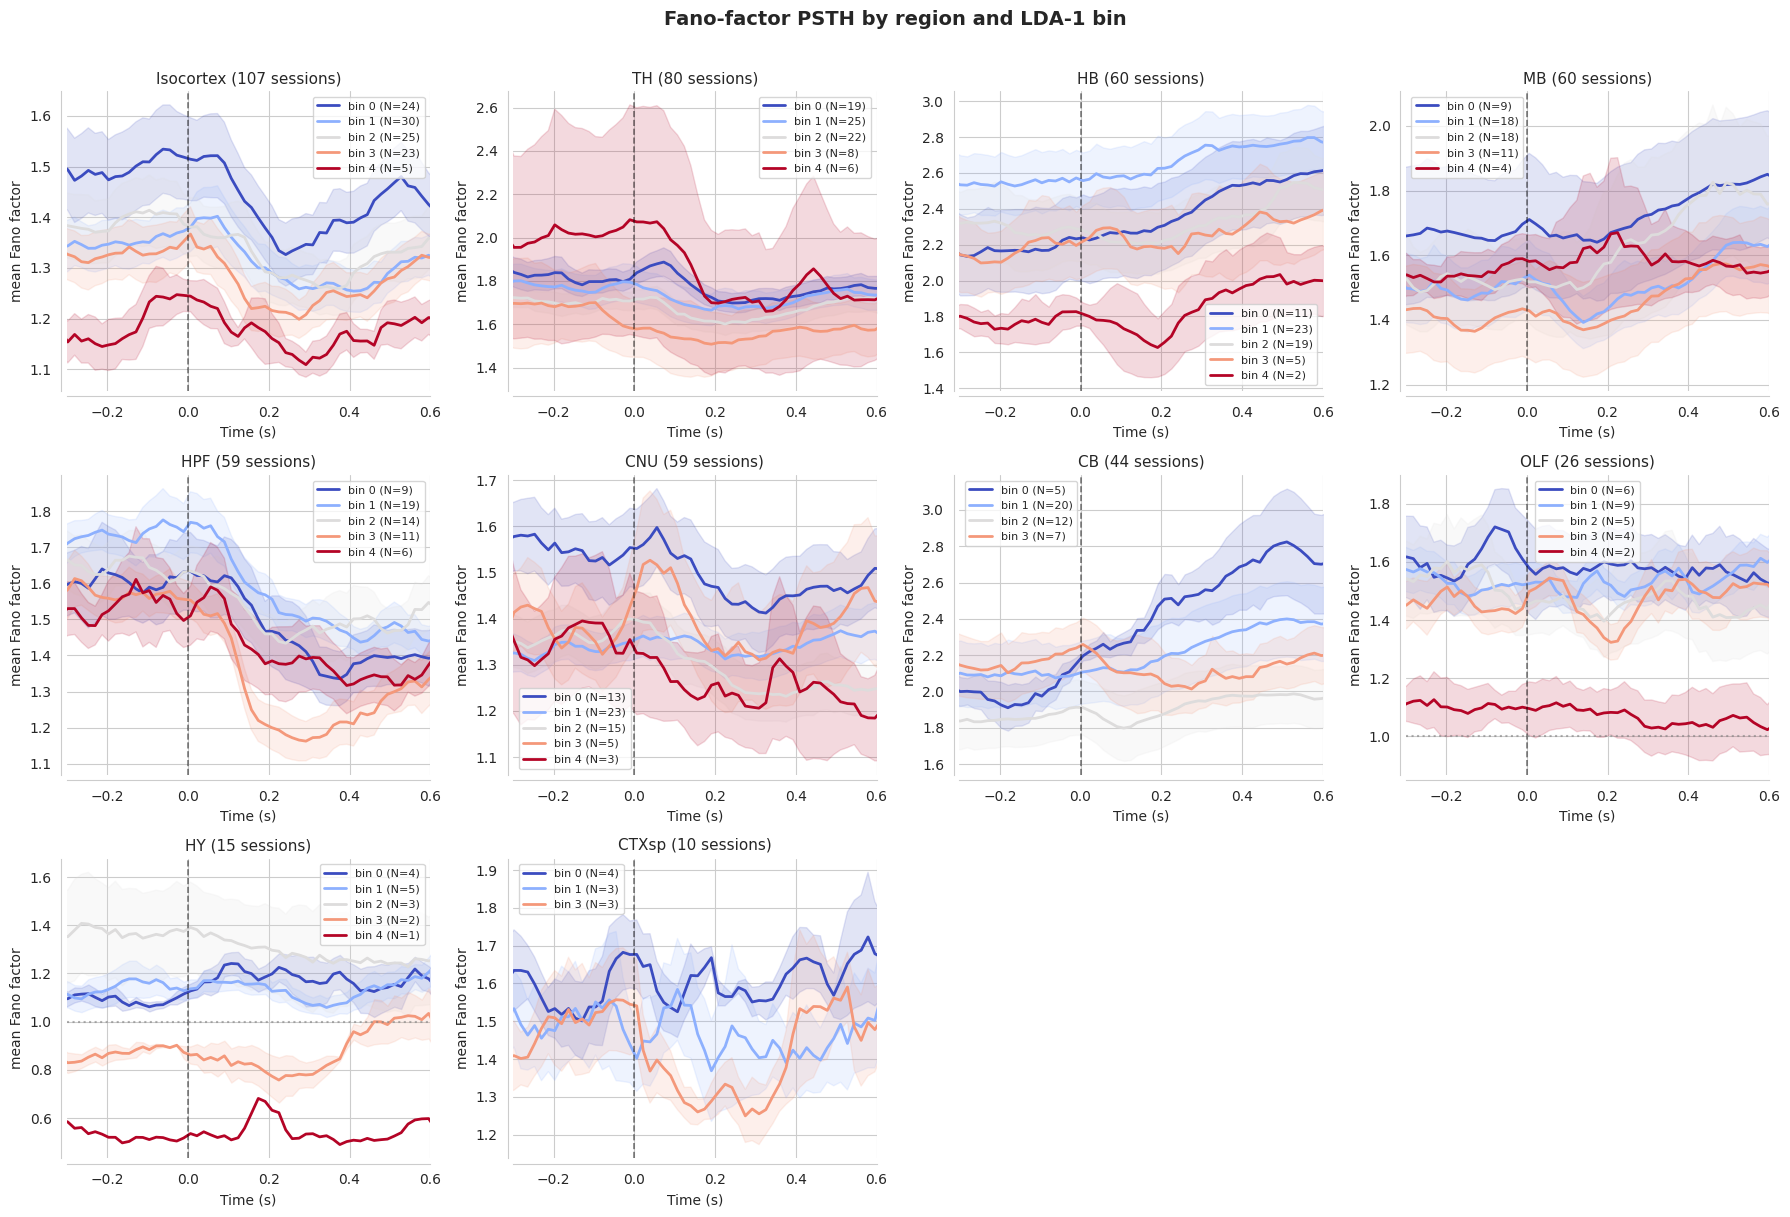

In [56]:
region_order = curves.groupby('region')['session'].nunique().sort_values(ascending=False).index.tolist()
ncols = 4; nrows = int(np.ceil(len(region_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
for k, region in enumerate(region_order):
    plot_one(axes[k // ncols][k % ncols], curves[curves['region'] == region],
             f'{region} ({curves[curves.region==region]["session"].nunique()} sessions)')
for k in range(len(region_order), nrows * ncols):
    axes[k // ncols][k % ncols].axis('off')
fig.suptitle('Fano-factor PSTH by region and LDA-1 bin', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

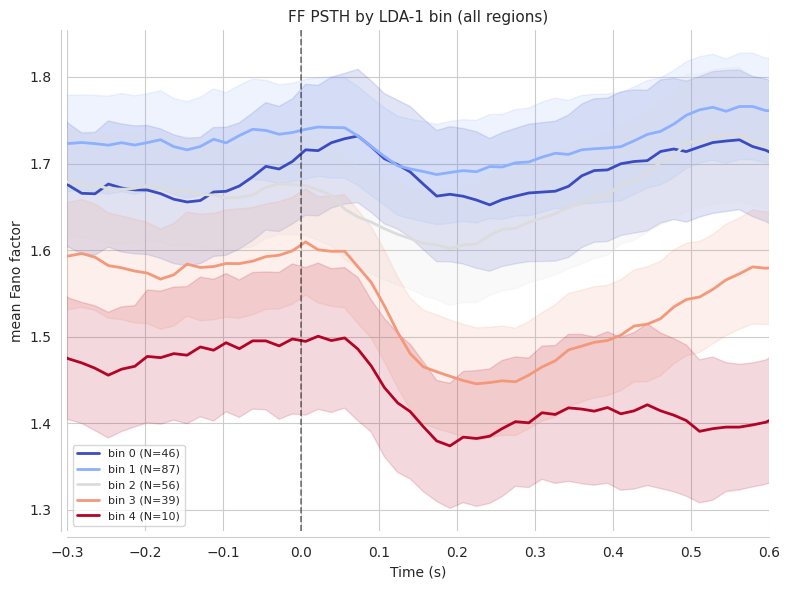

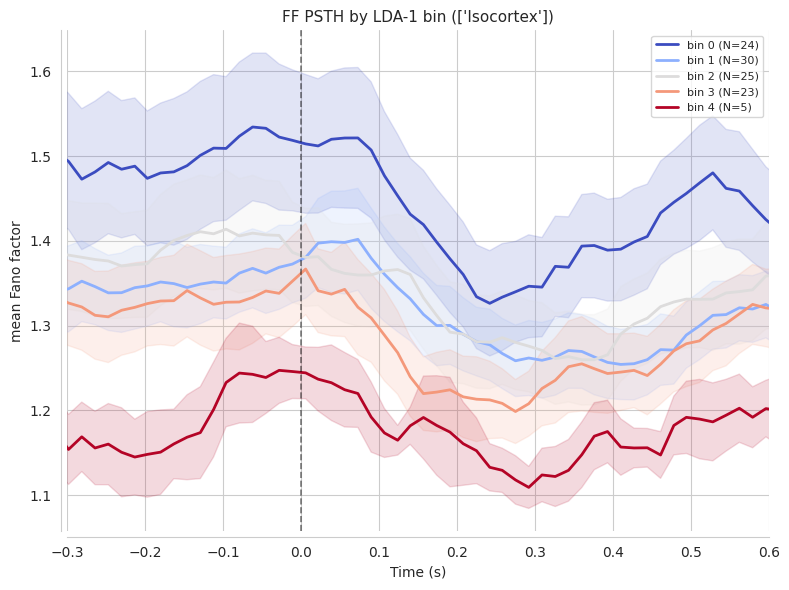

In [ ]:
plot_regions(regions=None)              # averaged across all regions
# plot_regions(regions=['Isocortex'])     # a specific region (edit as needed)

## Plot: baseline-subtracted FF PSTH per region (baseline = -0.2..0 s)
Same curves as above, but each session's trace has its mean Fano factor over the -0.2..0 s
baseline window subtracted before averaging, so every trace starts at ~0 and the panels show the
stimulus-evoked *change* in FF (isolating the quench). The baseline window is marked with a light
grey background band.

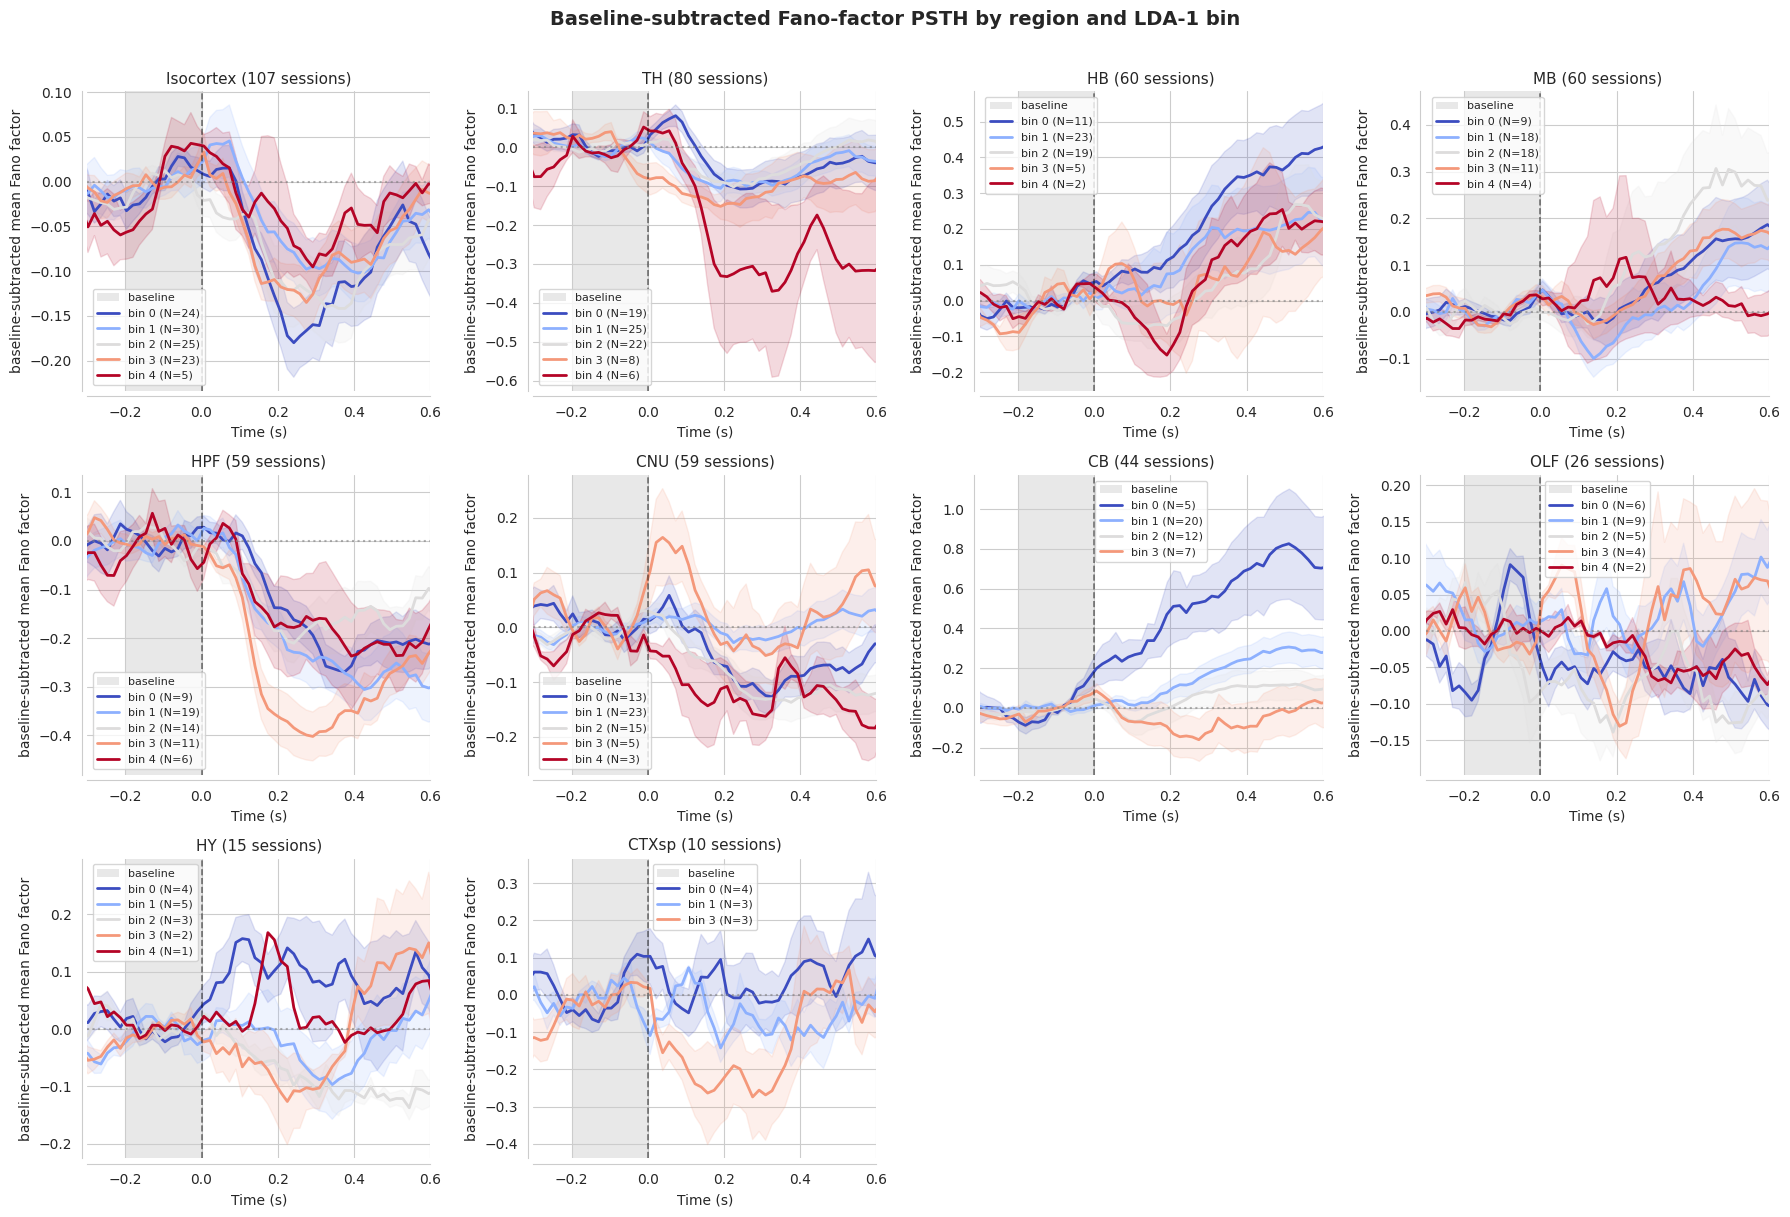

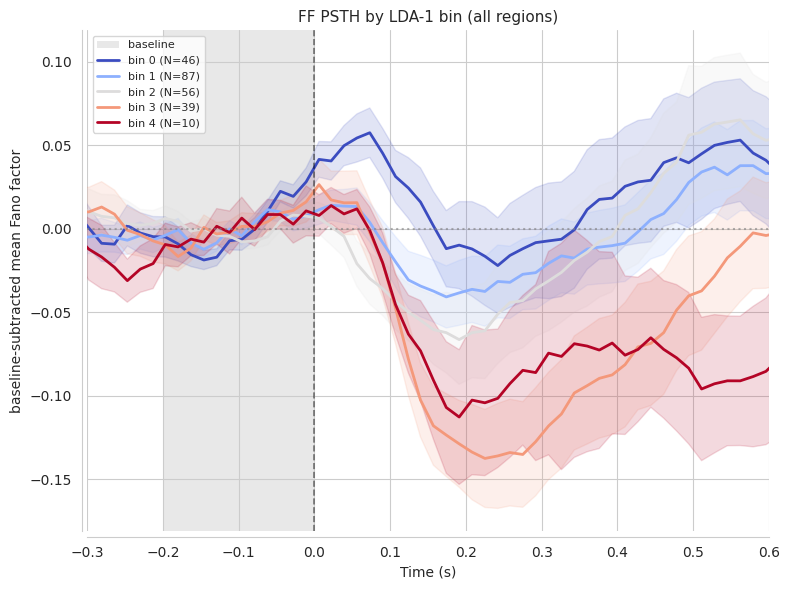

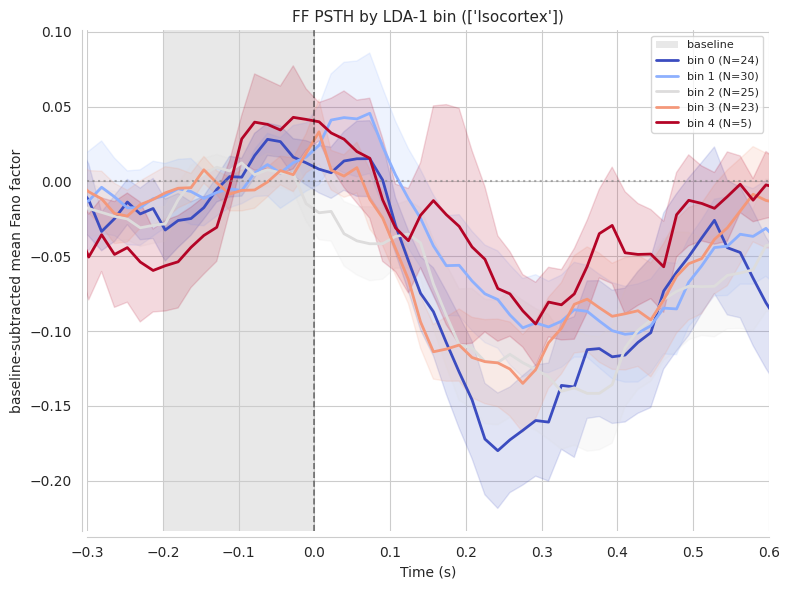

In [58]:
region_order = curves.groupby('region')['session'].nunique().sort_values(ascending=False).index.tolist()
ncols = 4; nrows = int(np.ceil(len(region_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
for k, region in enumerate(region_order):
    plot_one(axes[k // ncols][k % ncols], curves[curves['region'] == region],
             f'{region} ({curves[curves.region==region]["session"].nunique()} sessions)',
             baseline_subtract=True)
for k in range(len(region_order), nrows * ncols):
    axes[k // ncols][k % ncols].axis('off')
fig.suptitle('Baseline-subtracted Fano-factor PSTH by region and LDA-1 bin', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# all regions pooled + a single region, baseline-subtracted
plot_regions(regions=None, baseline_subtract=True)
plot_regions(regions=['Isocortex'], baseline_subtract=True)

## Plot: raw FF PSTH per region with pre/post windows shaded
Raw (not baseline-subtracted) Fano-factor PSTH, with the pre-stimulus window (-0.2..0 s) and
post-stimulus window (0..0.2 s) — the two windows used for the single-neuron FF metric — marked as
light grey background bands (`shade='prepost'`).

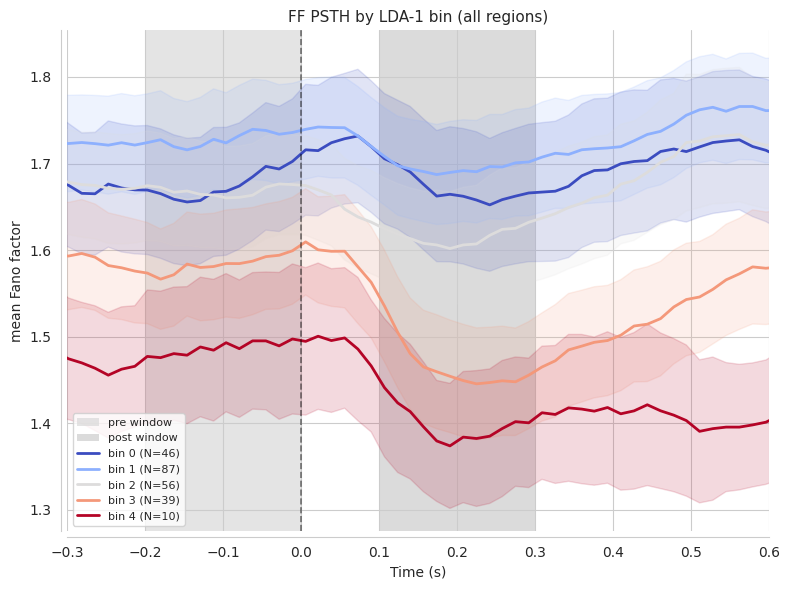

In [59]:
# region_order = curves.groupby('region')['session'].nunique().sort_values(ascending=False).index.tolist()
# ncols = 4; nrows = int(np.ceil(len(region_order) / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
# for k, region in enumerate(region_order):
#     plot_one(axes[k // ncols][k % ncols], curves[curves['region'] == region],
#              f'{region} ({curves[curves.region==region]["session"].nunique()} sessions)',
#              baseline_subtract=False, shade='prepost')
# for k in range(len(region_order), nrows * ncols):
#     axes[k // ncols][k % ncols].axis('off')
# fig.suptitle('Fano-factor PSTH by region and LDA-1 bin (pre/post windows shaded)', y=1.01, fontsize=14, fontweight='bold')
# plt.tight_layout(); plt.show()

# all regions pooled + a single region, raw FF with pre/post shaded
plot_regions(regions=None, shade='prepost')
# plot_regions(regions=['Isocortex'], shade='prepost')

## Single-neuron Fano factor vs LDA-1: GLM + session-permutation test + Bayes factor
Following the Methods: `(pre, post) log Fano Factor ~ predictor + C(cluster_region) + n_trials`
and `Fano Factor quench ~ predictor + C(cluster_region) + n_trials`, with `predictor = lda_1` here
(replacing `age_years`). Raw pre/post FF are log-transformed (right-skewed, strictly positive);
FF_quench is a signed difference so it stays on its natural scale -- same rule the paper applies.

A third test targets **when** the quench happens rather than its magnitude. `ff_quench.ipynb`
actually contains two different onset algorithms under two different headers; this replicates the
second, more sophisticated one (the one with a per-region interaction model and forest plot,
under its "## Timing of quench onset" section), not the simpler peak/trough-later-time approach
used earlier in that same notebook:
1. Find the neuron's FF "bump" peak within a **narrow window right at stimulus onset**,
   `PEAK_SEARCH_WINDOW = (-0.05, 0.08)` s -- not anywhere in the full search window.
2. Take the time-derivative of the (Gaussian-smoothed) FF curve.
3. Walk forward from that peak to the **first time the derivative crosses `ONSET_THRESHOLD_FRAC`
   (25%) of its steepest post-peak downward slope** -- a standard velocity-threshold onset-latency
   method. Falls back to the peak time if no crossing is found.

This targets *when the drop starts*, not *where the curve eventually bottoms out* -- the latter
(what the simpler block computes, and what an earlier version of this cell replicated) is
insensitive to onset timing once FF plateaus at a low value.

The region covariate for this test is the **bespoke functional grouping** `ff_quench.ipynb` uses
here (Hippocampus / Thalamus / Visual / Motor / Somatosensory cortex called out by name/ancestry,
everything else falls back to its Cosmos parent) -- not this notebook's own `cosmos`/`beryl`
option -- computed once as `functional_region` alongside `quench_onset_time`.

Two differences remain that can't be closed from this machine: the original's FF PSTH comes from
a different, legacy raw-data pipeline (capped at the first 500 trials/neuron) that only exists on
the remote server, and it applies none of this notebook's `MIN_NEURONS`/`MIN_TRIALS` quality
gates. The onset time is tested the same way as the other metrics here:
`quench_onset_time ~ lda_1 + C(functional_region) + n_trials`, on its natural scale (it's a signed
time, not a positive/skewed quantity) -- an additive GLM + permutation + BF, rather than the
original's `lda_1 * C(area)` interaction fit via `mixedlm` with a session random intercept.

The GLM slope of `lda_1` is the test statistic. Its permutation null shuffles `lda_1` across
**sessions** while keeping all neurons within a session yoked together (same session-based
shuffling the paper uses for neural metrics), refitting the slope each iteration (n=2000).

In place of the R `BayesFactor` package, the Bayes factor is the partial-correlation JZS Bayes
factor (Wetzels & Wagenmakers, 2012), computed via `pingouin.bayesfactor_pearson` after
residualizing both the metric and `lda_1` on the other covariates (Frisch-Waugh-Lovell theorem).
For a single coefficient in a Gaussian linear model this targets the same quantity the paper's
`BayesFactor`/Pingouin combination reports, without needing R/rpy2 in this environment.

In [60]:
def _design_matrix(df, region_col='region', extra_covars=('n_trials',)):
    """Intercept + region dummies (drop first) + extra numeric covariates, as a plain array."""
    dummies = pd.get_dummies(df[region_col], drop_first=True)
    Z = pd.concat([pd.Series(1.0, index=df.index, name='Intercept'), dummies,
                   df[list(extra_covars)].astype(float)], axis=1)
    return Z.values.astype(float)

def age_effect_test(df, y_col, predictor='lda_1', region_col='region', extra_covars=('n_trials',),
                     n_perm=N_PERM, seed=SEED, label=None):
    """Mimics the paper's age-effect test with `predictor` (here lda_1) in place of age_years:
    GLM slope as test statistic, session-stratified permutation p-value, and a partial-correlation
    Bayes factor in place of the R BayesFactor package."""
    d = df.dropna(subset=[y_col, predictor, region_col] + list(extra_covars)).reset_index(drop=True)
    y = d[y_col].values.astype(float)
    x = d[predictor].values.astype(float)
    Z = _design_matrix(d, region_col, extra_covars)
    Zpinv = np.linalg.pinv(Z)

    # Frisch-Waugh-Lovell: residualize y and the predictor on all other covariates once; the
    # slope of y_resid on x_resid equals the predictor's coefficient in the full multiple GLM.
    y_resid = y - Z @ (Zpinv @ y)
    x_resid_obs = x - Z @ (Zpinv @ x)
    slope_obs = np.sum(x_resid_obs * y_resid) / np.sum(x_resid_obs ** 2)

    r_partial, _ = pearsonr(x_resid_obs, y_resid)
    n_eff = max(len(d) - (Z.shape[1] - 1), 3)   # drop df used by region dummies + extra covariates
    bf10 = pg.bayesfactor_pearson(r_partial, n_eff)

    # Permutation: shuffle the predictor across SESSIONS (not neurons), preserving within-session
    # grouping, as in the paper's session-based label shuffling for neural metrics.
    sess_to_x = d.groupby('session')[predictor].first()
    sess_index = d['session'].values
    rng = np.random.default_rng(seed)
    perm_slopes = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = pd.Series(rng.permutation(sess_to_x.values), index=sess_to_x.index)
        x_perm = shuffled.reindex(sess_index).values.astype(float)
        x_perm_resid = x_perm - Z @ (Zpinv @ x_perm)
        perm_slopes[i] = np.sum(x_perm_resid * y_resid) / np.sum(x_perm_resid ** 2)
    p_perm = np.mean(np.abs(perm_slopes) >= np.abs(slope_obs))

    # Sanity-check fit via statsmodels GLM (Gaussian, identity link) for a human-readable summary.
    gdf = d.copy(); gdf['_y'] = y
    formula = f"_y ~ {predictor} + C({region_col}) + " + ' + '.join(extra_covars)
    glm_fit = smf.glm(formula, data=gdf, family=sm.families.Gaussian()).fit()

    return dict(label=label or y_col, n=len(d), n_sessions=d['session'].nunique(),
                slope=slope_obs, r_partial=r_partial, bf10=bf10, p_perm=p_perm,
                glm_slope=glm_fit.params[predictor], glm_p=glm_fit.pvalues[predictor])

def bf_label(bf):
    if bf > 10: return 'strong H1'
    if bf > 3: return 'moderate H1'
    if bf < 1 / 10: return 'strong H0'
    if bf < 1 / 3: return 'moderate H0'
    return 'inconclusive'

results = {
    'FF_pre (log)': age_effect_test(neuron_df, 'log_ff_pre',
                                     label='log FF_pre ~ lda_1 + C(region) + n_trials'),
    'FF_post (log)': age_effect_test(neuron_df, 'log_ff_post',
                                      label='log FF_post ~ lda_1 + C(region) + n_trials'),
    'FF_quench': age_effect_test(neuron_df, 'ff_quench',
                                  label='FF_quench ~ lda_1 + C(region) + n_trials'),
    'Quench onset time': age_effect_test(neuron_df, 'quench_onset_time', region_col='functional_region',
                                          label='Quench_onset_time ~ lda_1 + C(functional_region) + n_trials'),
}

print(f"{'metric':<20}{'n':>7}{'n_sess':>8}{'slope':>10}{'r_partial':>11}{'BF10':>10}{'evidence':>14}{'p_perm':>10}")
for name, r in results.items():
    print(f"{name:<20}{r['n']:>7}{r['n_sessions']:>8}{r['slope']:>10.4f}{r['r_partial']:>11.4f}"
          f"{r['bf10']:>10.3g}{bf_label(r['bf10']):>14}{r['p_perm']:>10.4f}")

metric                    n  n_sess     slope  r_partial      BF10      evidence    p_perm
FF_pre (log)          18850     238    0.0005     0.0024   0.00964     strong H0    0.9165
FF_post (log)         18850     238   -0.0099    -0.0495  1.03e+08     strong H1    0.0415
FF_quench             18850     238    0.0195     0.0519  9.41e+08     strong H1    0.0000
Quench onset time     18791     238   -0.0011    -0.0642  5.94e+14     strong H1    0.0000


## Fano factor vs LDA-1 (session-averaged for display; test statistics from the single-neuron GLM above)
Points and color both encode `lda_1` (coolwarm), matching the styling in `ff_vs_age.ipynb`.
Regression lines are only drawn when `BF10 > 3` (moderate-or-better evidence for H1), the same
plotting convention the paper uses.

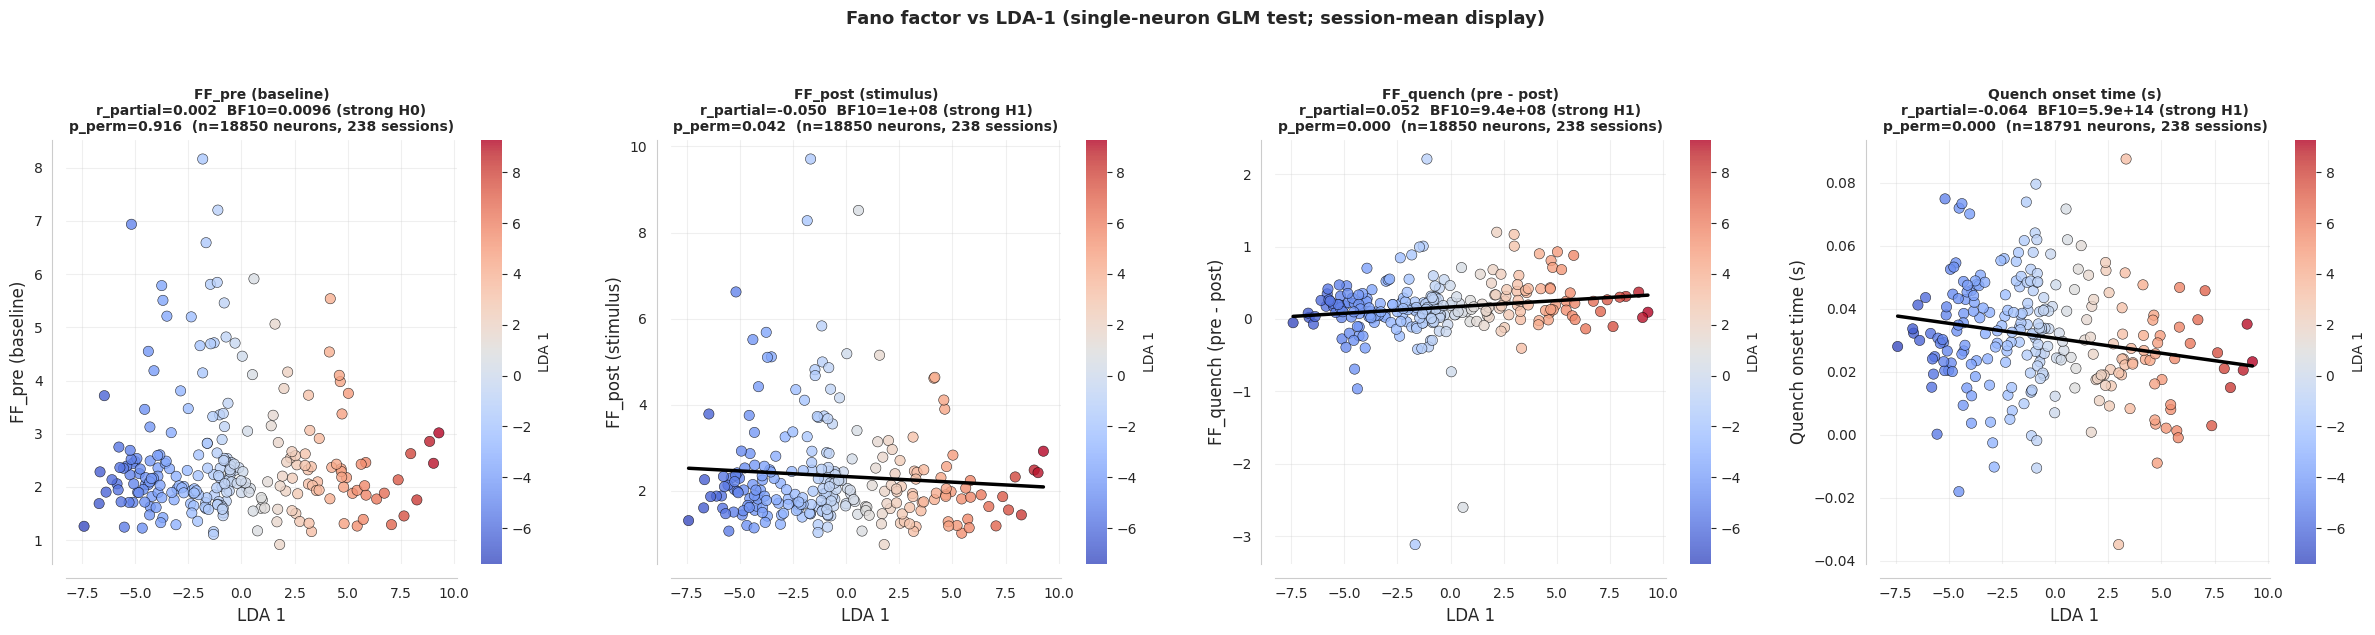

In [61]:
session_ff = neuron_df.groupby('session').agg(
    ff_pre=('ff_pre', 'mean'), ff_post=('ff_post', 'mean'), ff_quench=('ff_quench', 'mean'),
    quench_onset_time=('quench_onset_time', 'mean'), lda_1=('lda_1', 'first')).reset_index()

panels = [('ff_pre', 'FF_pre (baseline)', results['FF_pre (log)']),
          ('ff_post', 'FF_post (stimulus)', results['FF_post (log)']),
          ('ff_quench', 'FF_quench (pre - post)', results['FF_quench']),
          ('quench_onset_time', 'Quench onset time (s)', results['Quench onset time'])]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, (col, title, res) in zip(axes, panels):
    d = session_ff.dropna(subset=[col, 'lda_1'])
    x = d['lda_1'].values; y = d[col].values
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=55, edgecolors='black', linewidth=0.4)
    if res['bf10'] > 3:   # paper's convention: only draw the line with >= moderate evidence for H1
        z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5)
    cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
    ax.set_xlabel('LDA 1', fontsize=12); ax.set_ylabel(title, fontsize=12)
    ax.set_title(f"{title}\nr_partial={res['r_partial']:.3f}  BF10={res['bf10']:.2g} ({bf_label(res['bf10'])})\n"
                 f"p_perm={res['p_perm']:.3f}  (n={res['n']} neurons, {res['n_sessions']} sessions)",
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=10)
fig.suptitle('Fano factor vs LDA-1 (single-neuron GLM test; session-mean display)', y=1.05, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Mean-matched Fano factor (control for firing rate — Churchland et al. 2010)

Single-neuron Fano factor is itself rate-dependent (refractoriness makes high-rate spiking more
regular → lower FF), so a FF drop after stimulus onset — or a FF difference across LDA-1 bins —
could be a trivial by-product of a firing-rate change rather than a genuine change in trial-to-trial
variability. The mean-matching method (Churchland et al. 2010, *Nat Neurosci*) controls for this:
before computing FF for the groups being compared, we discard neurons so the **distribution of mean
spike counts is identical across all groups**. Any residual FF difference then cannot be attributed
to the mean rate.

Two comparisons are matched here:
1. **Across time (the quench):** equalize the mean-count distribution across every time bin, so the
   post-stimulus FF drop is shown to survive rate-matching. Whole population.
2. **Across LDA-1 bins:** equalize the mean-count distribution across all (LDA-1 bin × time) slots
   simultaneously, so any FF-vs-LDA-1 difference is rate-controlled both over time and between bins.

Implementation notes:
- FF here is the **mean of per-neuron var/mean ratios** on the matched sample (consistent with
  `ff_curve` elsewhere in this notebook), not Churchland's variance-vs-mean regression slope.
- Variance is condition-adjusted (side × contrast residuals) and counts are the same
  `WIN_BINS`-smoothed windowed counts as the descriptive PSTH, so it sits on the same footing.
- The "greatest common distribution" is the per-mean-count-bin minimum over all groups; matching
  therefore discards data, and the retained neuron count per slot is printed. If it is very small
  (large rate shifts leave little overlap), loosen `MM_N_HIST` or widen the tail clip.
- This re-reads the firing-rate files (a second pass) to get per-neuron **mean and variance time
  courses**, which the main compute cell does not store.

In [62]:
# --- mean-matching parameters ---
MM_XLIM = (-0.3, 0.6)    # time window over which FF is mean-matched and plotted
MM_N_HIST = 20           # mean-count histogram bins used for distribution matching
MM_N_REPEATS = 50        # random equalizing subsamples to average FF over
MM_REGIONS = None        # None = all regions pooled; or a list of cosmos acronyms e.g. ['Isocortex']

mm_mask = (tsec >= MM_XLIM[0]) & (tsec <= MM_XLIM[1])
tsec_mm = tsec[mm_mask]

# Second pass over the files: per-neuron mean spike count and condition-adjusted variance, per
# time bin (the main compute cell only keeps region-averaged curves + collapsed window metrics).
mean_rows, var_rows, bin_rows = [], [], []
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        if session not in bin_map: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values * binwidth

        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        reg_keep = np.isin(neu_area, MM_REGIONS) if MM_REGIONS is not None else np.ones(len(neurons), dtype=bool)
        if not reg_keep.any(): continue

        conds = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values
        corr_set = correct_by_session.get(session, set())
        correct_mask = np.array([t in corr_set for t in trials]) if CORRECT_ONLY else np.ones(len(trials), dtype=bool)
        valid_idx = np.where(correct_mask)[0]

        Aw = smooth_time(A[reg_keep][:, valid_idx, :], WIN_BINS, SMOOTH_MODE) * WIN_BINS  # neurons x trials x T counts
        cond_valid = conds[valid_idx]
        mean_nt = np.nanmean(Aw, axis=1)                                                  # neurons x T
        if REMOVE_CONDITION:
            resid = Aw.astype(float).copy()
            for cc in pd.unique(cond_valid):
                ci = np.where(cond_valid == cc)[0]
                resid[:, ci, :] -= np.nanmean(Aw[:, ci, :], axis=1, keepdims=True)
            var_nt = np.nanvar(resid, axis=1, ddof=1)
        else:
            var_nt = np.nanvar(Aw, axis=1, ddof=1)
        mean_rows.append(mean_nt[:, mm_mask])
        var_rows.append(var_nt[:, mm_mask])
        bin_rows.append(np.full(int(reg_keep.sum()), bin_map[session]))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

MM_MEAN = np.vstack(mean_rows)          # neurons x Tw : mean spike count
MM_VAR = np.vstack(var_rows)            # neurons x Tw : condition-adjusted variance
MM_BIN = np.concatenate(bin_rows)       # neurons      : LDA-1 bin
MM_VALID = np.isfinite(MM_MEAN) & np.isfinite(MM_VAR) & (MM_MEAN > MIN_MEAN_COUNT)
print(f"Mean-matching pool: {MM_MEAN.shape[0]} neurons x {MM_MEAN.shape[1]} time bins "
      f"({MM_XLIM[0]}..{MM_XLIM[1]} s); neurons per LDA-1 bin: {np.bincount(MM_BIN, minlength=N_BINS).tolist()}")


def _mm_edges(mean_mat, valid, n_hist):
    """Mean-count histogram bin edges; the long tail is clipped at the 99th percentile so bins are
    not wasted on a handful of very-high-rate neurons (the top bin catches everything above p99)."""
    vals = mean_mat[valid]
    edges = np.linspace(vals.min(), np.nanpercentile(vals, 99), n_hist + 1)
    edges[-1] = np.inf
    return edges

def matched_ff(slots, edges, n_repeats, seed):
    """slots: list of (means, vars) arrays paired per valid neuron in that slot. Equalizes the
    mean-count histogram across ALL slots to their greatest common distribution, then returns the
    mean-matched Fano factor (mean of var/mean ratios) per slot, averaged over n_repeats random
    equalizations, plus the retained neuron count per slot (same for every slot by construction)."""
    nb = len(edges) - 1
    binidx = [np.clip(np.digitize(m, edges) - 1, 0, nb - 1) for (m, v) in slots]
    hist = np.array([[int(np.sum(bi == k)) for k in range(nb)] for bi in binidx])
    common = hist.min(axis=0)
    rng_mm = np.random.default_rng(seed)
    ff = np.full((n_repeats, len(slots)), np.nan)
    for r in range(n_repeats):
        for si, (m, v) in enumerate(slots):
            bi = binidx[si]; sel = []
            for k in range(nb):
                if common[k] == 0: continue
                pool = np.where(bi == k)[0]
                sel.extend(rng_mm.choice(pool, common[k], replace=False))
            if sel:
                sel = np.array(sel)
                ff[r, si] = np.nanmean(v[sel] / m[sel])
    return np.nanmean(ff, axis=0), int(common.sum())

def raw_ff_curve(mean_mat, var_mat, valid):
    """Unmatched mean-of-ratios FF per time bin, over the valid neurons at each time."""
    out = np.full(mean_mat.shape[1], np.nan)
    for t in range(mean_mat.shape[1]):
        vt = valid[:, t]
        if vt.any():
            out[t] = np.nanmean(var_mat[vt, t] / mean_mat[vt, t])
    return out

print("Helpers ready: matched_ff(), raw_ff_curve(), _mm_edges()")

  100/380 files...
  200/380 files...
  300/380 files...
Mean-matching pool: 34550 neurons x 54 time bins (-0.3..0.6 s); neurons per LDA-1 bin: [6670, 11183, 9251, 5215, 2231]
Helpers ready: matched_ff(), raw_ff_curve(), _mm_edges()


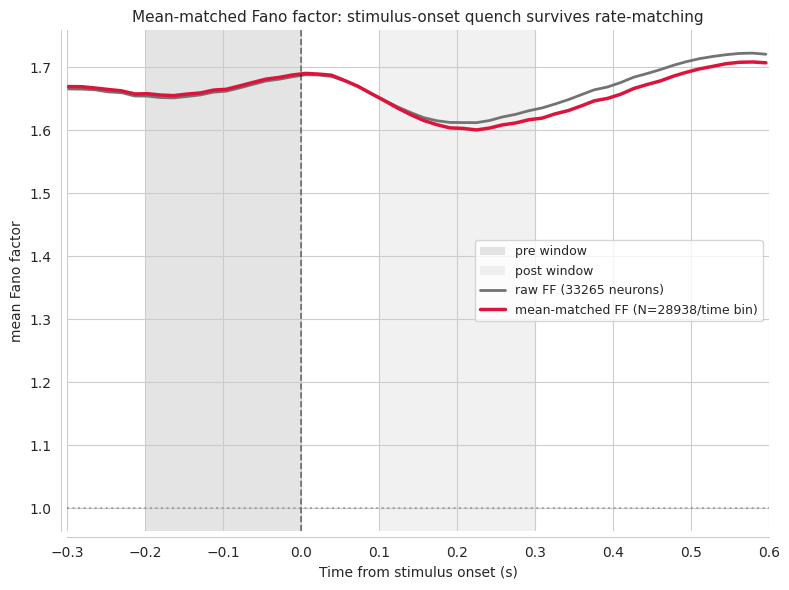

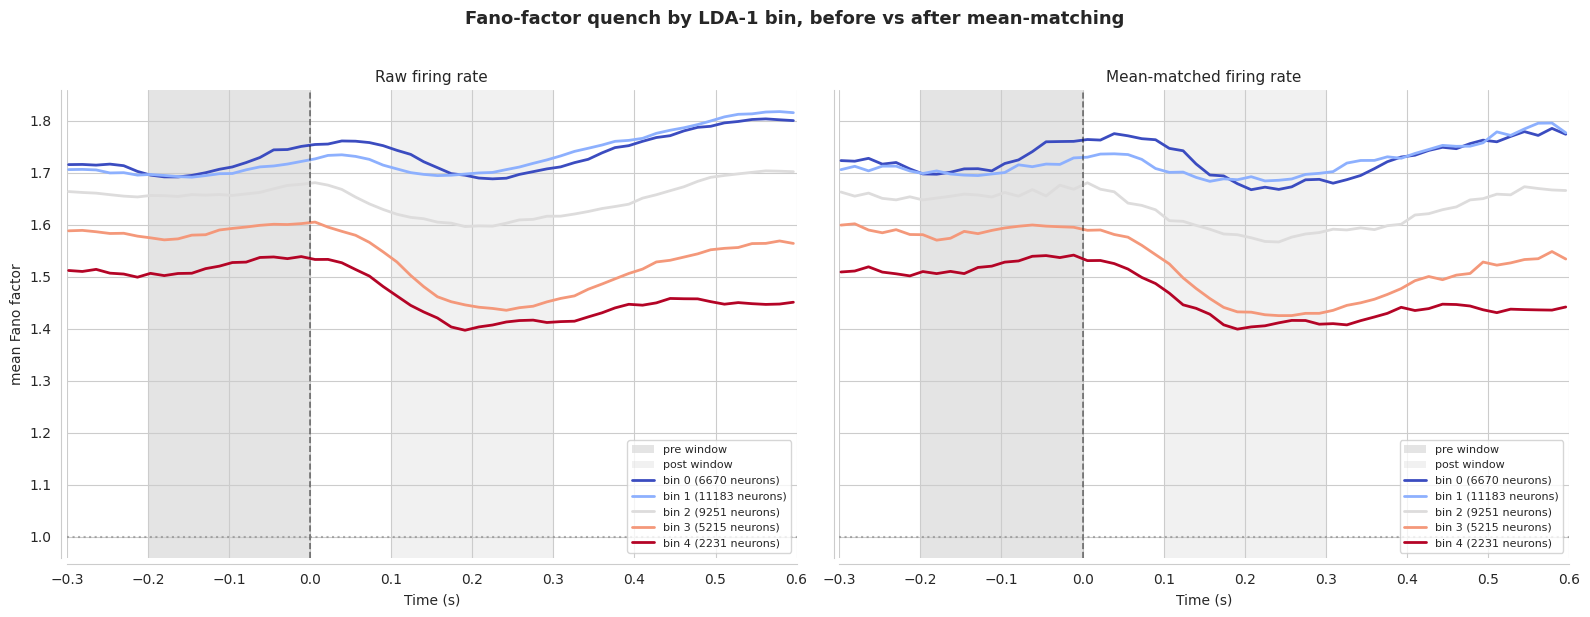

Population: raw FF at baseline vs post-window minimum, and matched retained N=28938/time.
Per-bin matched retained N=1818/bin-time slot (common distribution over 270 slots).


In [65]:
def _shade_prepost(ax):
    ax.axvspan(PRE_WINDOW[0], PRE_WINDOW[1], color='0.85', alpha=0.7, lw=0, zorder=0, label='pre window')
    ax.axvspan(POST_WINDOW[0], POST_WINDOW[1], color='0.85', alpha=0.35, lw=0, zorder=0, label='post window')

edges = _mm_edges(MM_MEAN, MM_VALID, MM_N_HIST)

# === (1) Population: raw vs mean-matched FF time course (the quench, rate-controlled) ===
slots_t = [(MM_MEAN[MM_VALID[:, t], t], MM_VAR[MM_VALID[:, t], t]) for t in range(len(tsec_mm))]
mm_ff, mm_N = matched_ff(slots_t, edges, MM_N_REPEATS, SEED)
raw_ff = raw_ff_curve(MM_MEAN, MM_VAR, MM_VALID)
n_pool = int(MM_VALID.any(axis=1).sum())

fig, ax = plt.subplots(figsize=(8, 6))
_shade_prepost(ax)
ax.plot(tsec_mm, raw_ff, color='0.45', lw=2, label=f'raw FF ({n_pool} neurons)')
ax.plot(tsec_mm, mm_ff, color='crimson', lw=2.5, label=f'mean-matched FF (N={mm_N}/time bin)')
ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
ax.axhline(1.0, color='gray', ls=':', alpha=0.6)
ax.set_xlabel('Time from stimulus onset (s)'); ax.set_ylabel('mean Fano factor'); ax.set_xlim(list(MM_XLIM))
ax.set_title('Mean-matched Fano factor: stimulus-onset quench survives rate-matching', fontsize=11)
ax.legend(fontsize=9); sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

# === (2) Per LDA-1 bin: raw vs mean-matched, one common mean-count distribution across all
#         (bin x time) slots -> rate-controlled both over time AND between bins ===
bins_present = [b for b in range(N_BINS) if (MM_BIN == b).any()]
slots, slot_bt = [], []
for b in bins_present:
    mb = MM_BIN == b
    Mb, Vb, Vld = MM_MEAN[mb], MM_VAR[mb], MM_VALID[mb]
    for t in range(len(tsec_mm)):
        vt = Vld[:, t]
        slots.append((Mb[vt, t], Vb[vt, t])); slot_bt.append((b, t))
mm_ff_bt, mm_N_bt = matched_ff(slots, edges, MM_N_REPEATS, SEED)

matched_by_bin = {b: np.full(len(tsec_mm), np.nan) for b in bins_present}
for (b, t), val in zip(slot_bt, mm_ff_bt):
    matched_by_bin[b][t] = val
raw_by_bin = {b: raw_ff_curve(MM_MEAN[MM_BIN == b], MM_VAR[MM_BIN == b], MM_VALID[MM_BIN == b])
              for b in bins_present}

colors = plt.cm.coolwarm(np.linspace(0, 1, N_BINS))
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, curves_by_bin, ttl in [(axes[0], raw_by_bin, 'Raw firing rate'),
                               (axes[1], matched_by_bin, f'Mean-matched firing rate')]:
    _shade_prepost(ax)
    for b in bins_present:
        n_b = int((MM_BIN == b).sum())
        ax.plot(tsec_mm, curves_by_bin[b], color=colors[b], lw=2, label=f'bin {b} ({n_b} neurons)')
    ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
    ax.axhline(1.0, color='gray', ls=':', alpha=0.6)
    ax.set_xlabel('Time (s)'); ax.set_xlim(list(MM_XLIM)); ax.set_title(ttl, fontsize=11)
    ax.legend(fontsize=8); sns.despine(ax=ax, offset=4)
axes[0].set_ylabel('mean Fano factor')
fig.suptitle('Fano-factor quench by LDA-1 bin, before vs after mean-matching', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Population: raw FF at baseline vs post-window minimum, and matched retained N={mm_N}/time.")
print(f"Per-bin matched retained N={mm_N_bt}/bin-time slot (common distribution over {len(slots)} slots).")